In [14]:
import pandas as pd
import numpy as np
import sys
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import concordance_index
import matplotlib.pyplot as plt
from lifelines.statistics import logrank_test
from typing import Dict, Optional, Tuple, Any, List
import math

sys.path.append("/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/")
from SynOmics.processing.metadata import MetaData
dataset_dict = {}
original_data = pd.read_csv("../../Data/original_data.csv", index_col = 0)
dataset_dict["Origin"] = original_data
seed = 42
syn_datas = [f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
synthetic_data_dictionary = {}
for i, tool in enumerate(syn_datas):
    syn_df = pd.read_csv(f"../../Data/{syn_datas[i]}.csv", index_col = 0)
    dataset_dict[tool] = syn_df

            Datasets    pvalue              C-index                     HR
0             Origin  0.002765                0.554  0.582\n (0.406-0.833)
1       avatarsk5_42  0.162708                0.529  0.784\n (0.556-1.104)
2      avatarsk10_42  0.042115                0.538  0.702\n (0.498-0.989)
3           ctgan_42  0.131933                0.531  1.301\n (0.923-1.835)
4  gaussiancopula_42  0.046822                0.539  0.698\n (0.488-0.997)
5        synthpop_42  0.146162                0.533  0.756\n (0.517-1.105)
6            tvae_42       NaN  insufficient events    insufficient events


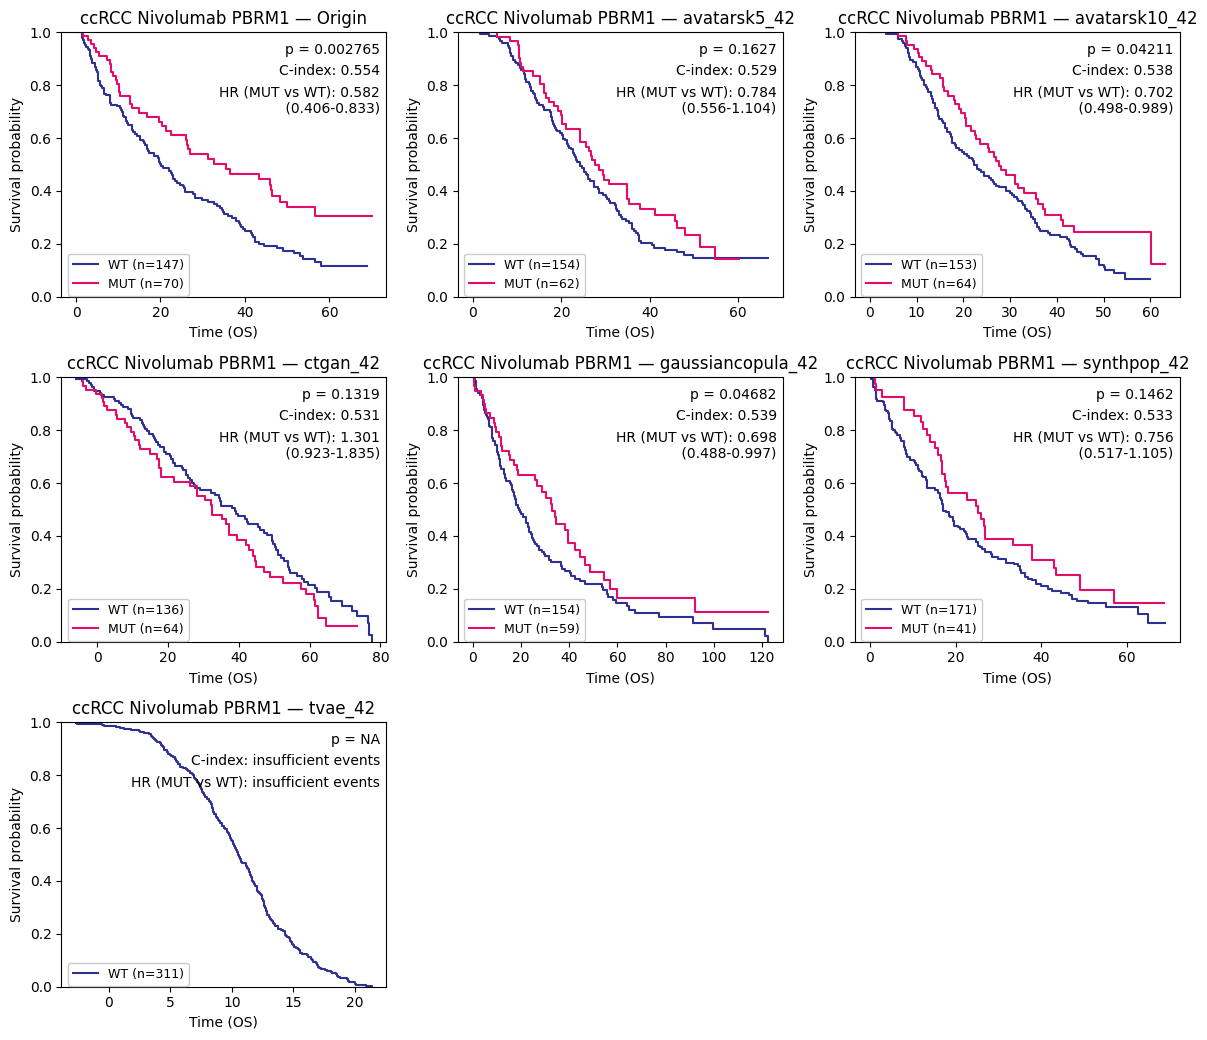

In [15]:
from SurvivalAnalysis import plot_survival_grid
import os

os.makedirs(f"SA_PBRM1/Seed_{seed}", exist_ok = True)

phenotype = {"PBRM1": ["MUT", "WT"]}
    
fig, summary = plot_survival_grid(
    dataset_dict,
    phenotype=phenotype,
    treatment=None,
    time_target="OS",
    event_target="OS_CNSR",
    ncols=3,
    figsize=None,
    show_censors=False,
    ci_show=False,
    title_prefix="ccRCC Nivolumab PBRM1",
)

print(summary)
fig.savefig(f"SA_PBRM1/Seed_{seed}/KMCurve.png", dpi=300, bbox_inches="tight")
plt.show()
summary.to_csv(f'SA_PBRM1/Seed_{seed}/Summary.csv',index = False)

In [16]:
from SurvivalAnalysis import compute_similarity_scores

scored = compute_similarity_scores(summary, original_name="Origin")
pvalues = scored["pvalue_score"].values
cindex_scores = scored["C-index_score"].values
hr_scores = scored["HR_score"].values
avarages_scores = 1/3*(pvalues+cindex_scores+hr_scores)
scored["Average"] = avarages_scores
scored.to_csv(f'SA_PBRM1/Seed_{seed}/Scores.csv', index = False)
scored

,Datasets,pvalue,C-index,HR,pvalue_score,C-index_score,HR_score,Average
0,Origin,0.002765,0.554,0.582\n (0.406-0.833),1.000000,1.000,1.000000,1.000000
1,avatarsk5_42,0.162708,0.529,0.784\n (0.556-1.104),0.840057,0.975,0.742347,0.852468
2,avatarsk10_42,0.042115,0.538,0.702\n (0.498-0.989),0.960650,0.984,0.829060,0.924570
3,ctgan_42,0.131933,0.531,1.301\n (0.923-1.835),0.870832,0.977,0.447348,0.765060
4,gaussiancopula_42,0.046822,0.539,0.698\n (0.488-0.997),0.955943,0.985,0.833811,0.924918
5,synthpop_42,0.146162,0.533,0.756\n (0.517-1.105),0.856603,0.979,0.769841,0.868481
6,tvae_42,NaN,insufficient events,insufficient events,NaN,NaN,NaN,NaN
